In [1]:
import torch, os
import numpy as np
import torch.nn as nn
print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import importlib, subprocess, sys
for pkg,pip in [("skimage","scikit-image"),("cv2","opencv-python-headless"),("matplotlib","matplotlib")]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable,"-m","pip","install","-q",pip])
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
print("deps ready")

PyTorch: 2.11.0+cpu | CUDA: False
deps ready


## Upload checkpoint

In [2]:
CKPT = "model_005.pth"
if not os.path.exists(CKPT):
    try:
        from google.colab import files
        print("Upload model_005.pth ...")
        up = files.upload()
        # if uploaded under a different name, grab the first .pth
        if CKPT not in up:
            pths = [k for k in up if k.endswith(".pth")]
            if pths: CKPT = pths[0]
    except Exception as e:
        print("Manual upload needed. Put model_005.pth in the working dir.", e)
assert os.path.exists(CKPT), "Checkpoint not found - upload model_005.pth first."
print("Using checkpoint:", CKPT)

Upload model_005.pth ...


Saving model_030.pth to model_030 (1).pth
Using checkpoint: model_030 (1).pth


## Build the BatchNorm architecture and load the weights


In [3]:
class DnCNN(nn.Module):
    def __init__(self, depth=17, n_channels=64, image_channels=1, kernel_size=3):
        super().__init__()
        pad = kernel_size//2
        layers = [nn.Conv2d(image_channels, n_channels, kernel_size, padding=pad, bias=True),
                  nn.ReLU(inplace=True)]
        for _ in range(depth-2):
            layers += [nn.Conv2d(n_channels, n_channels, kernel_size, padding=pad, bias=False),
                       nn.BatchNorm2d(n_channels, eps=1e-4, momentum=0.95),
                       nn.ReLU(inplace=True)]
        layers += [nn.Conv2d(n_channels, image_channels, kernel_size, padding=pad, bias=False)]
        self.dncnn = nn.Sequential(*layers)
    def forward(self, x):
        return x - self.dncnn(x)     # residual learning

model = DnCNN().to(device)

state = torch.load(CKPT, map_location=device)
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]

# In case the checkpoint is a whole model object rather than a state_dict
if not isinstance(state, dict):
    model = state.to(device)
    print("Loaded a full model object.")
else:
    missing, unexpected = model.load_state_dict(state, strict=False)
    print(f"Loaded state_dict | missing {len(missing)} | unexpected {len(unexpected)}")
    if missing:    print("  missing e.g.:", missing[:4])
    if unexpected: print("  unexpected e.g.:", unexpected[:4])

model.eval()   # CRITICAL: BatchNorm uses stored running stats in eval mode
print("Model ready, in eval mode.")

Loaded state_dict | missing 0 | unexpected 0
Model ready, in eval mode.


## Load Set12

In [4]:
import urllib.request, cv2
os.makedirs("Set12", exist_ok=True)
base = "https://raw.githubusercontent.com/cszn/DnCNN/master/testsets/Set12"
imgs = []
for n in range(1,13):
    p = f"Set12/{n:02d}.png"
    if not os.path.exists(p):
        try: urllib.request.urlretrieve(f"{base}/{n:02d}.png", p)
        except Exception as e: print("dl fail", n, e)
    if os.path.exists(p):
        imgs.append(cv2.imread(p,0).astype("float32")/255.0)
print("Set12 images:", len(imgs))

Set12 images: 12


## Evaluate on Set12 (sigma=25)


In [6]:
SIGMA = 25

@torch.no_grad()
def denoise(clean, sigma, seed=0):
    rng = np.random.default_rng(seed)
    noisy = clean + rng.normal(0, sigma/255.0, clean.shape)
    t = torch.from_numpy(noisy).float().unsqueeze(0).unsqueeze(0).to(device)
    den = model(t).squeeze().cpu().numpy()
    return np.clip(noisy,0,1), np.clip(den,0,1)

def metrics(c,t): return psnr(c,t,data_range=1.0), ssim(c,t,data_range=1.0)

ps, ss = [], []
for k,clean in enumerate(imgs):
    _, den = denoise(clean, SIGMA, seed=k)
    p,s = metrics(clean, den); ps.append(p); ss.append(s)

print(f"Your trained DnCNN-S (sigma=25) on Set12:")
print(f"  average PSNR = {np.mean(ps):.2f} dB")
print(f"  average SSIM = {np.mean(ss):.3f}")
print(f"  (training-time epoch-30 probe was ~30.41 dB; pretrained reference ~30.44 dB)")

Your trained DnCNN-S (sigma=25) on Set12:
  average PSNR = 30.41 dB
  average SSIM = 0.862
  (training-time epoch-30 probe was ~30.41 dB; pretrained reference ~30.44 dB)


## Visual check 

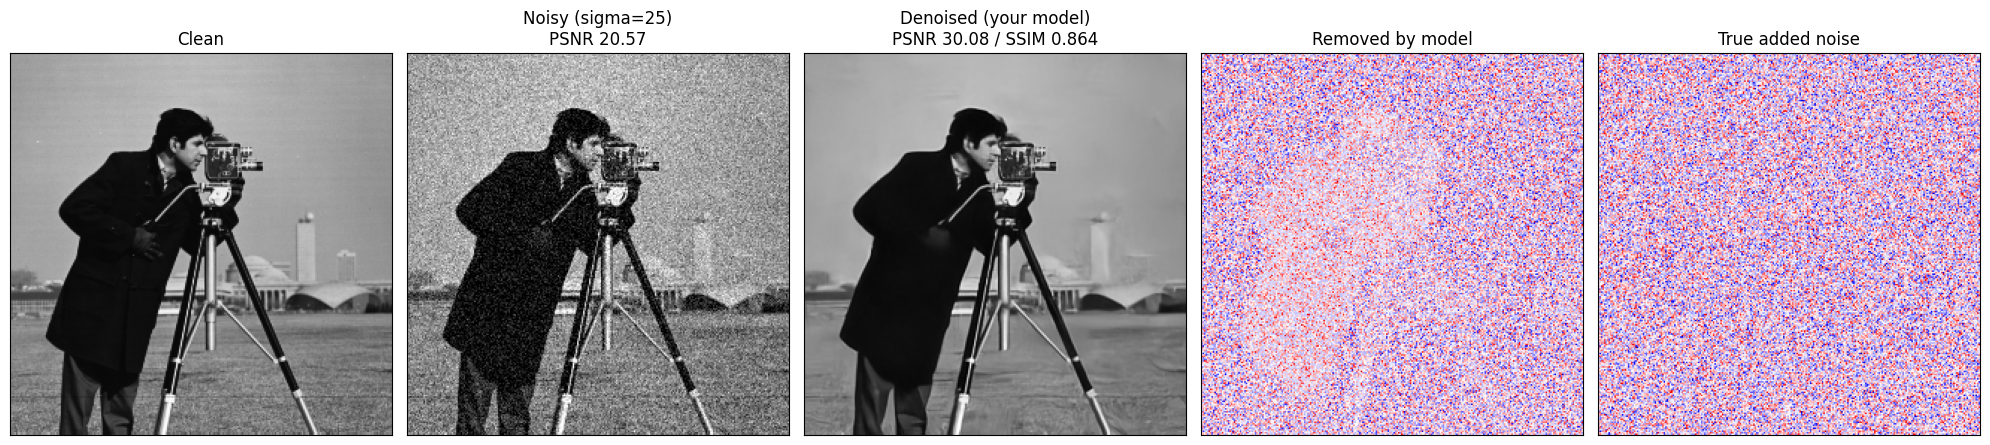

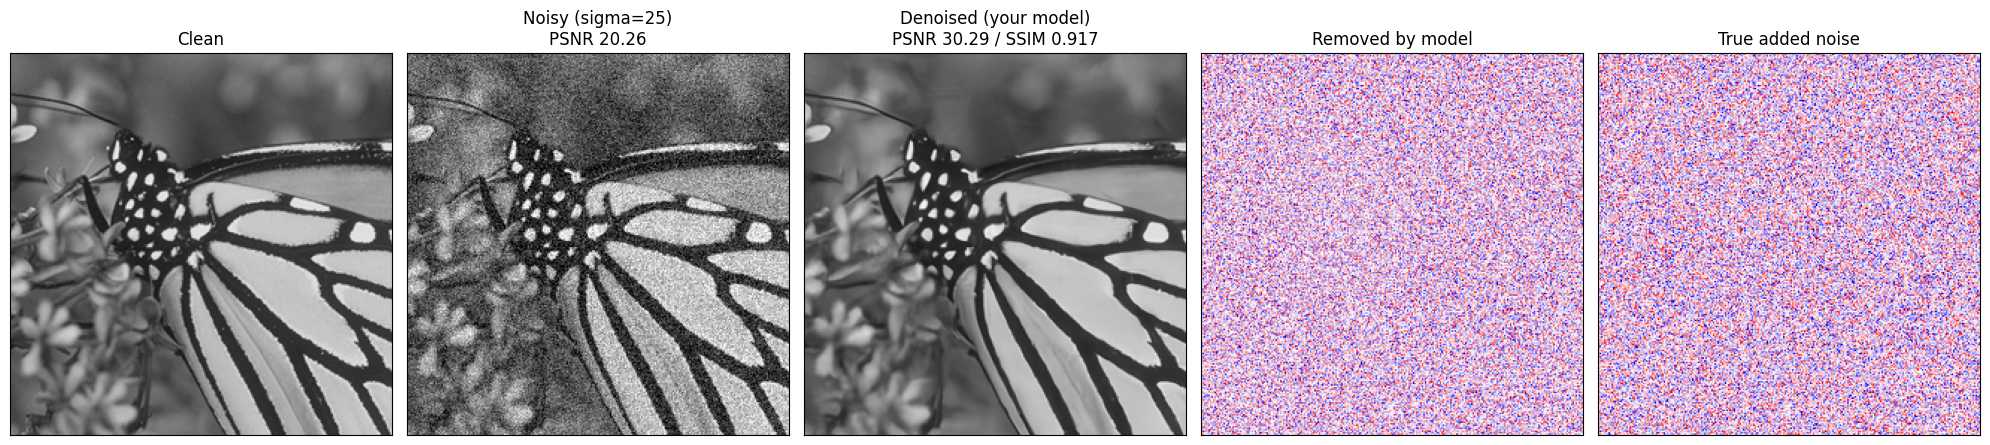

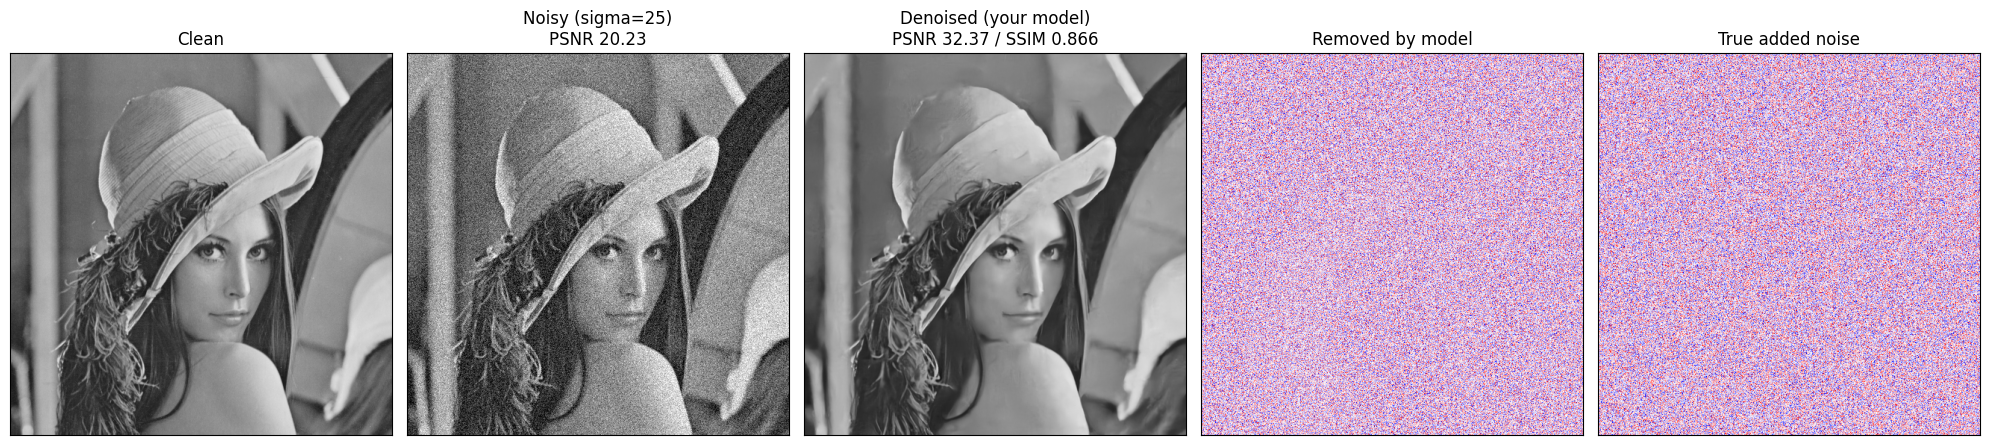

In [7]:
def show(idx, sigma=SIGMA, seed=0):
    clean = imgs[idx]
    rng = np.random.default_rng(seed)
    true_noise = rng.normal(0, sigma/255.0, clean.shape)
    noisy, den = denoise(clean, sigma, seed)
    removed = noisy - den
    p_n,_ = metrics(clean, noisy); p_d,s_d = metrics(clean, den)
    lim = max(abs(removed).max(), abs(true_noise).max())

    fig, ax = plt.subplots(1,5, figsize=(20,4.5))
    ax[0].imshow(clean, cmap="gray", vmin=0, vmax=1); ax[0].set_title("Clean")
    ax[1].imshow(noisy, cmap="gray", vmin=0, vmax=1); ax[1].set_title(f"Noisy (sigma={sigma})\nPSNR {p_n:.2f}")
    ax[2].imshow(den, cmap="gray", vmin=0, vmax=1);   ax[2].set_title(f"Denoised (your model)\nPSNR {p_d:.2f} / SSIM {s_d:.3f}")
    ax[3].imshow(removed, cmap="seismic", vmin=-lim, vmax=lim); ax[3].set_title("Removed by model")
    ax[4].imshow(true_noise, cmap="seismic", vmin=-lim, vmax=lim); ax[4].set_title("True added noise")
    for a in ax: a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); plt.show()

for idx in [0, 4, 7]:
    show(idx)